In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from PF2nlfff.utils.data import samples
LL_data = samples().LL
nx,ny,nz = LL_data.shape[1:]
boundary = LL_data[...,0].copy()
bound_tensor = torch.from_numpy(boundary).float()

In [3]:
import gc
from PF2nlfff import PROGAN
gc.collect()
torch.cuda.empty_cache()
device = 'cuda:1'
progan = PROGAN(bound_tensor,device=device)
res = progan(
    nz = nz,
    nn_config=dict(
        epoch=10000,
        print_epoch=500,
        Delta = 10,
        gamma = 0.994,
        L_div = 1.e-1,
        L_ff  = 1.e-2,
        L_lf  = 1.e-1,
        ),
    )

================================== Extrapolating Potential Field ===================================
 nx:101 | ny:101 | nz:51
 device: cuda:1
Batch Size/Total Size: 105258/520251
 Wall Time:     0.019 [min]


===================================== Fast NLFFF Extrapolation =====================================
 Initial: fi=7.49477e-03 | sj=9.60614e-01 | L=1.46480e+08
 Final  : fi=8.23914e-03 | sj=2.42368e-01 | L=8.22980e+05

 Wall Time:     0.480 [min]
================================== Physics-Reinforced Retraining ===================================
Clip data from torch.Size([3, 101, 101, 51]) to torch.Size([3, 96, 96, 48])
Iter 00001, Loss: 6.555e+06, Loss_div: 5.835e+06,Loss_ff: 1.194e+05, Loss_bc: 5.678e+05, Loss_lf: 3.177e+04, wall_time: 4.672e-01 sec, lr: 1.000e-03
Iter 00500, Loss: 5.648e+03, Loss_div: 3.729e+02,Loss_ff: 3.209e+02, Loss_bc: 4.799e+03, Loss_lf: 2.107e+01, wall_time: 4.996e+01 sec, lr: 7.401e-04
Iter 01000, Loss: 7.209e+02, Loss_div: 2.033e+02,Loss_ff: 1.547e+02, L

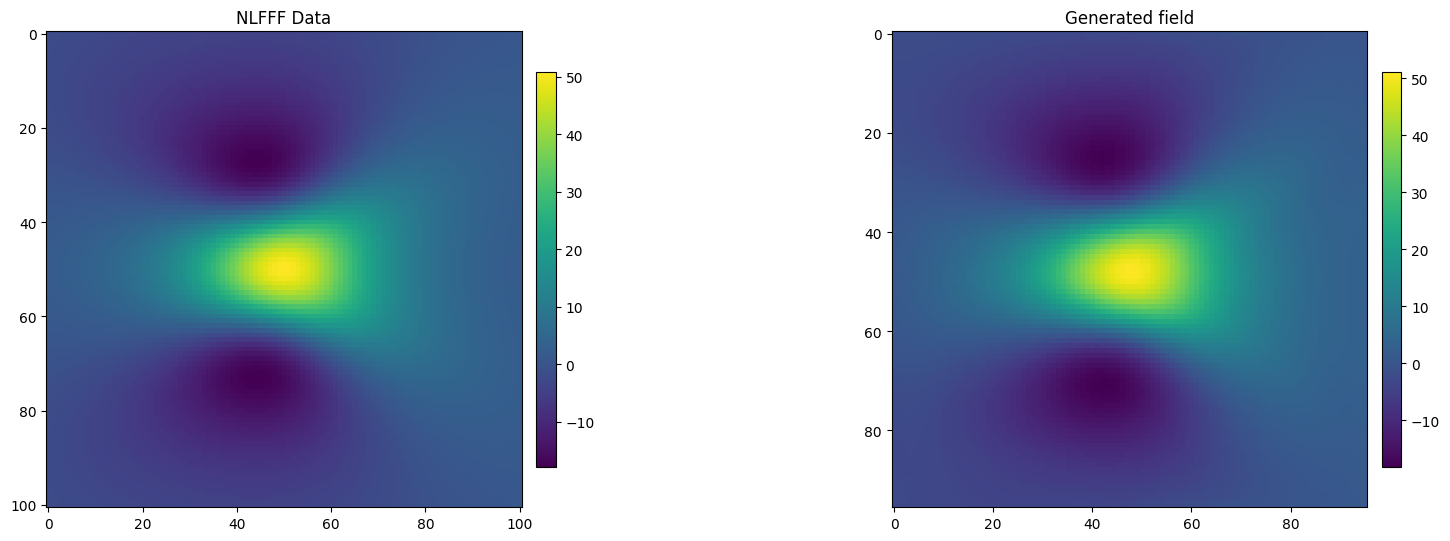

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PF2nlfff.utils.math import *
ref_data = LL_data.copy()
ret_data = res.nn.copy()
# ret_data = res.fast.copy()[...,:50]
# ret_data = nn_data.numpy()
plt.figure(figsize=(20,6.18))

zidx = 10
plt.subplot(121)
# plt.imshow(np.linalg.norm(rot(ref_data),axis=0).sum(axis=2),origin='lower',cmap='coolwarm', norm=matplotlib.colors.LogNorm())
plt.imshow(ref_data[2,...,zidx])
plt.title('NLFFF Data')
plt.colorbar(fraction=0.028, pad=0.02)

plt.subplot(122)
# plt.imshow(np.linalg.norm(rot(ret_data),axis=0).sum(axis=2),origin='lower',cmap='coolwarm', norm=matplotlib.colors.LogNorm())
plt.imshow(ret_data[2,...,zidx])
plt.title('Generated field')
plt.colorbar(fraction=0.028, pad=0.02)
plt.show()